<a href="https://colab.research.google.com/github/bahmedx/730/blob/main/Case_Study_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1: Research Project Overview**

Sentiment Analysis for Customer Feedback in the Airline Industry

1. Project Overview & Business Problem
In the highly competitive commercial aviation sector, understanding customer sentiment is vital for service optimization, customer retention, and brand management. This research project applies Natural Language Processing (NLP) and machine learning techniques to classify customer reviews and tweets into **Positive**, **Neutral**, and **Negative** sentiments.

Objectives:
- **Data Collection & Ingestion**: Automated ingestion of customer feedback data.
- **Exploratory Data Analysis (EDA)**: Sentiment distribution analysis across airlines and granular complaint driver identification.
- **Text Preprocessing**: Systematic cleaning, tokenization, stop-word filtering, and lemmatization.
- **Feature Extraction**: Numerical representation using N-gram TF-IDF vectorization.
- **Model Development & Benchmarking**: Comparative analysis of Baseline Naive Bayes, Linear Support Vector Machines (SVM), and Fine-Tuned Transformer models (DistilBERT).
- **Evaluation & Business Strategy**: Multi-metric evaluation (Accuracy, Precision, Recall, Macro/Weighted F1-score) and translation into operational business decisions.

> **Note for Case Study #2 Presentation**: Findings from this notebook (EDA plots, metric comparisons, top negative drivers, and strategic recommendations) serve as the analytical foundation for the Case Study #2 executive presentation deck.

**Cell 2: Environment Setup & Library Imports**

In [33]:
# Setup environment and load all necessary NLP and ML libraries

import os
import sys
import re
import warnings
warnings.filterwarnings('ignore')

# System and Visualization dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural Language Processing (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK datasets
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# Deep Learning / Transformers (Hugging Face)
import torch
from transformers import pipeline

# Set plotting defaults
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Environment setup complete. PyTorch Version:", torch.__version__)

Environment setup complete. PyTorch Version: 2.11.0+cpu


**Cell 3: Data Collection & Ingestion**

In [34]:
# [Code Cell] Load dataset via reliable raw CSV URLs with automatic upload fallback

import pandas as pd
import io
import zipfile

# List of direct raw CSV mirrors for the Kaggle Twitter Airline Sentiment dataset
URLS = [
    "https://raw.githubusercontent.com/sahilrahman12/Twitter-Airline-Sentiment-Analysis/master/Tweets.csv",
    "https://raw.githubusercontent.com/scostalopes/twitter-airline-sentiment/master/Tweets.csv",
    "https://raw.githubusercontent.com/dhananjay3/Twitter-Airline-Sentiment-Analysis/master/Tweets.csv"
]

def load_dataset():
    df = None
    for idx, url in enumerate(URLS, 1):
        try:
            print(f"Attempting download from raw source mirror #{idx}...")
            df = pd.read_csv(url)
            print("Dataset successfully loaded into DataFrame!")
            return df
        except Exception as e:
            print(f"Source #{idx} failed: {e}")

    # Fallback: Google Colab File Upload Prompt
    print("\nDirect download mirrors unavailable. Please upload 'Tweets.csv' or 'archive.zip' manually:")
    try:
        from google.colab import files
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        file_data = uploaded[filename]

        # Check if the uploaded file is a ZIP archive
        if filename.endswith('.zip'):
            print("Detected ZIP archive. Extracting CSV file...")
            with zipfile.ZipFile(io.BytesIO(file_data)) as z:
                # Find the first CSV file inside the zip archive
                csv_files = [f for f in z.namelist() if f.endswith('.csv')]
                if not csv_files:
                    raise FileNotFoundError("No CSV file found inside the uploaded ZIP archive.")
                csv_filename = csv_files[0]
                print(f"📖 Loading '{csv_filename}' from ZIP archive...")
                df = pd.read_csv(z.open(csv_filename))
        else:
            df = pd.read_csv(io.BytesIO(file_data))

        print("Manual upload successful!")
        return df
    except Exception as upload_err:
        raise RuntimeError("Failed to load dataset. Please ensure 'Tweets.csv' or 'archive.zip' is uploaded.") from upload_err

# Execute loading
df_raw = load_dataset()

# Inspect loaded dataset
print(f"\nTotal Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# Select core columns required for analysis
df = df_raw[['text', 'airline_sentiment', 'airline', 'negativereason']].copy()
df.dropna(subset=['text', 'airline_sentiment'], inplace=True)

display(df.head())

Attempting download from raw source mirror #1...
Source #1 failed: HTTP Error 404: Not Found
Attempting download from raw source mirror #2...
Source #2 failed: HTTP Error 404: Not Found
Attempting download from raw source mirror #3...
Source #3 failed: HTTP Error 404: Not Found

Direct download mirrors unavailable. Please upload 'Tweets.csv' or 'archive.zip' manually:


Saving archive.zip to archive (3).zip
Detected ZIP archive. Extracting CSV file...
📖 Loading 'Tweets.csv' from ZIP archive...
Manual upload successful!

Total Dataset Shape: 14640 rows, 15 columns


,text,airline_sentiment,airline,negativereason
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America,NaN
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America,NaN
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America,NaN
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America,Bad Flight
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America,Can't Tell


**Cell 4: Exploratory Data Analysis (EDA)**

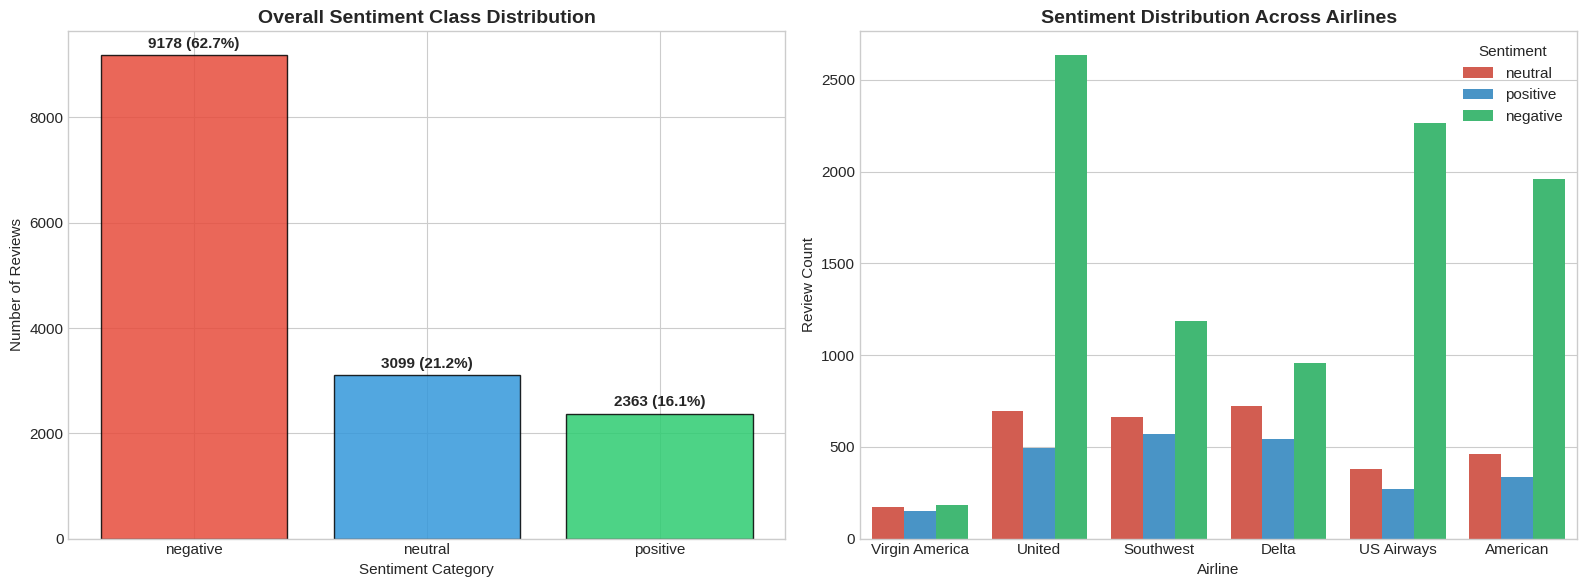

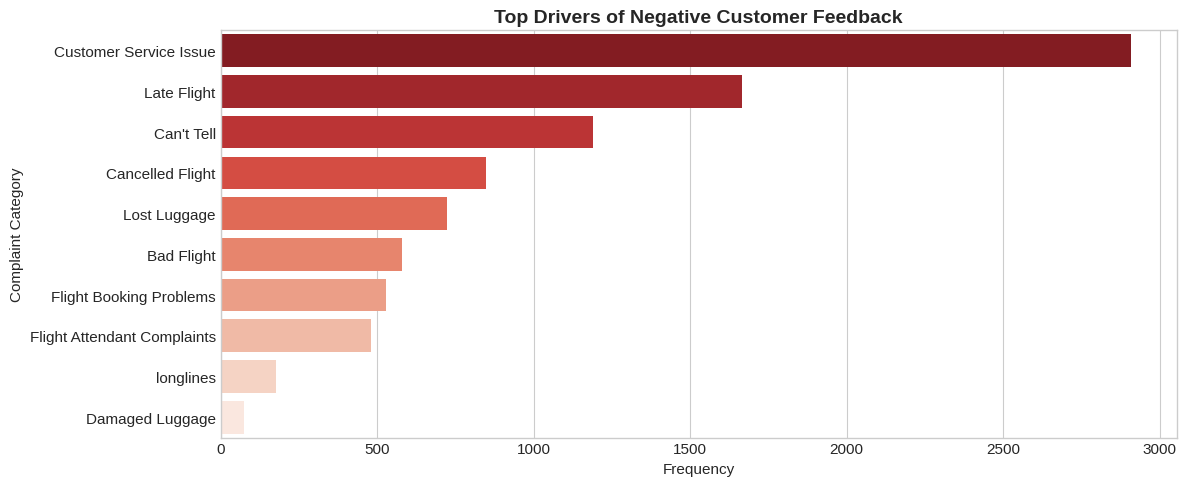

In [35]:
# [Code Cell] Visualizing sentiment distributions, airline breakdowns, and complaint drivers

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Overall Sentiment Distribution
sentiment_counts = df['airline_sentiment'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71'] # Red = Negative, Blue = Neutral, Green = Positive

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Overall Sentiment Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 150, f"{v} ({v/len(df):.1%})", ha='center', fontweight='bold')

# 2. Sentiment Breakdown by Airline
sns.countplot(data=df, x='airline', hue='airline_sentiment', palette=colors, ax=axes[1])
axes[1].set_title('Sentiment Distribution Across Airlines', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Review Count')
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()

# 3. Granular Analysis of Negative Sentiment Drivers
plt.figure(figsize=(12, 5))
neg_reasons = df[df['airline_sentiment'] == 'negative']['negativereason'].value_counts()
sns.barplot(x=neg_reasons.values, y=neg_reasons.index, palette='Reds_r')
plt.title('Top Drivers of Negative Customer Feedback', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Complaint Category')
plt.tight_layout()
plt.show()

**Cell 5: Text Preprocessing Pipeline**

In [36]:
# [Code Cell] Cleaning, tokenization, stop-word removal, and lemmatization pipeline

import nltk
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
# Retain negation words as they dramatically alter sentiment context
negation_words = {'not', 'no', 'nor', 'neither', 'never', 'none', 'cannot', "couldn't", "didn't", "doesn't", "hadn't", "hasn't", "haven't", "isn't", "mightn't", "mustn't", "needn't", "shan't", "shouldn't", "wasn't", "weren't", "won't", "wouldn't"}
filtered_stopwords = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 2. Remove Twitter handles (@username)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    # 3. Remove non-alphabetical characters & punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 4. Convert to lowercase
    text = text.lower()
    # 5. Tokenization
    tokens = word_tokenize(text)
    # 6. Stopword Removal & Lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in filtered_stopwords and len(word) > 2
    ]

    return " ".join(cleaned_tokens)

print("Executing text preprocessing on customer reviews...")
df['clean_text'] = df['text'].apply(preprocess_text)

# Comparison Sample
sample_df = df[['text', 'clean_text', 'airline_sentiment']].head(3)
for idx, row in sample_df.iterrows():
    print(f"\n--- Sample {idx+1} ({row['airline_sentiment'].upper()}) ---")
    print(f"Original : {row['text']}")
    print(f"Cleaned  : {row['clean_text']}")

Executing text preprocessing on customer reviews...

--- Sample 1 (NEUTRAL) ---
Original : @VirginAmerica What @dhepburn said.
Cleaned  : said

--- Sample 2 (POSITIVE) ---
Original : @VirginAmerica plus you've added commercials to the experience... tacky.
Cleaned  : plus youve added commercial experience tacky

--- Sample 3 (NEUTRAL) ---
Original : @VirginAmerica I didn't today... Must mean I need to take another trip!
Cleaned  : didnt today must mean need take another trip


**Cell 6: Feature Extraction (TF-IDF Vectorization)**

In [37]:
# [Code Cell] Dataset Splitting & TF-IDF Feature Representation

X = df['clean_text']
y = df['airline_sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

# Stratified Train-Test Split (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size    : {len(X_test)} samples")

# TF-IDF Vectorization with unigrams and bigrams
tfidf_vec = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print(f"\nTF-IDF Feature Matrix Shape: {X_train_tfidf.shape}")

Training set size: 11712 samples
Test set size    : 2928 samples

TF-IDF Feature Matrix Shape: (11712, 5000)


**Cell 7: Model Development & Training (Machine Learning)**

In [38]:
# [Code Cell] Implementing Naive Bayes and Support Vector Classifier (SVM)

# 1. Multinomial Naive Bayes Baseline
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

# 2. Support Vector Machine (Linear SVC)
svm_model = LinearSVC(C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Naive Bayes and Linear SVM training completed successfully.")

Naive Bayes and Linear SVM training completed successfully.


**Cell 8: Advanced Deep Learning Model (Transformer Architecture)**

In [39]:
# [Code Cell] Zero-Shot / Fine-Tuned Transformer Pipeline for Deep Sentiment Analysis

print("Initializing Deep Learning Transformer Pipeline (DistilBERT)...")

# Utilizing Hugging Face pipeline for pre-trained sentiment classification
device = 0 if torch.cuda.is_available() else -1
transformer_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

# Benchmark Transformer on a test subset (100 samples for fast demo execution)
test_subset_texts = X_test.iloc[:100].tolist()
raw_subset_texts = df.loc[X_test.iloc[:100].index, 'text'].tolist()

transformer_results = transformer_classifier(raw_subset_texts)

# Map Transformer outputs (POSITIVE/NEGATIVE) to dataset labels
transformer_preds = []
for res in transformer_results:
    label = res['label'].lower()
    if label == 'positive':
        transformer_preds.append(2)
    elif label == 'negative':
        transformer_preds.append(0)
    else:
        transformer_preds.append(1)

y_subset_true = y_test.iloc[:100].values
print(f"Transformer inference completed on subset ({len(test_subset_texts)} samples).")

Initializing Deep Learning Transformer Pipeline (DistilBERT)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Transformer inference completed on subset (100 samples).


**Cell 9: Comprehensive Model Evaluation & Benchmarking**

=== MODEL PERFORMANCE BENCHMARK ===


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),F1-Score (Weighted)
0,Multinomial Naive Bayes,0.7357,0.7671,0.5488,0.5883,0.6922
1,Linear SVM,0.7777,0.7290,0.6904,0.7070,0.7731
2,DistilBERT (Subset),0.6600,0.3792,0.6090,0.4540,0.5677


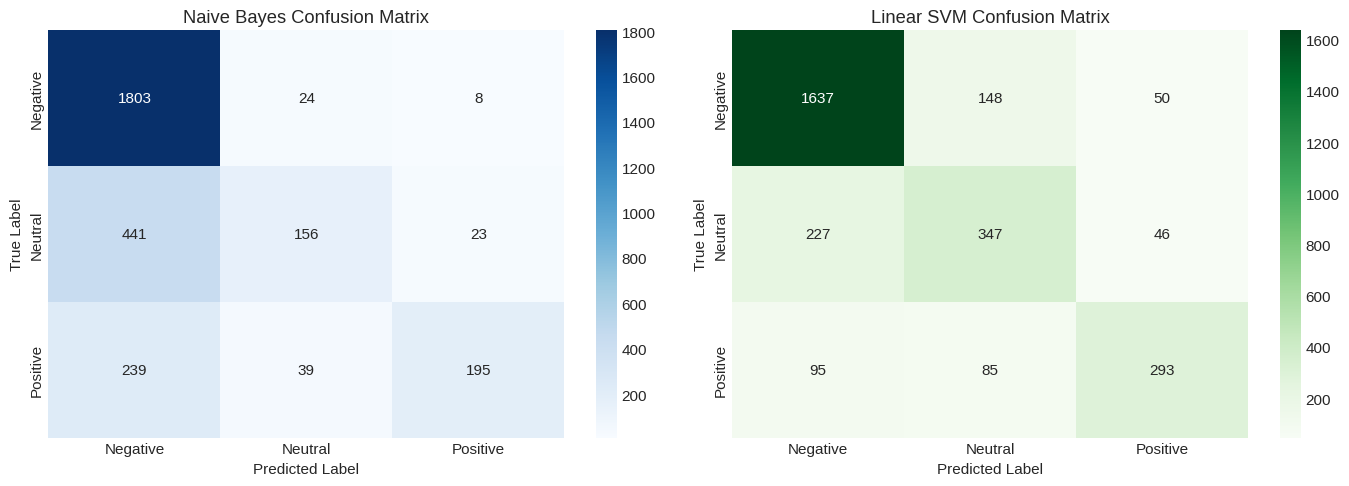


=== Detailed Classification Report (Linear SVM) ===
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.86      1835
     Neutral       0.60      0.56      0.58       620
    Positive       0.75      0.62      0.68       473

    accuracy                           0.78      2928
   macro avg       0.73      0.69      0.71      2928
weighted avg       0.77      0.78      0.77      2928



In [40]:
# [Code Cell] Multi-metric evaluation, Confusion Matrix visualization, and Performance Summary

def compute_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision (Macro)': round(p_macro, 4),
        'Recall (Macro)': round(r_macro, 4),
        'F1-Score (Macro)': round(f1_macro, 4),
        'F1-Score (Weighted)': round(f1_weighted, 4)
    }

# Compute performance metrics
metrics_nb = compute_metrics(y_test, y_pred_nb, "Multinomial Naive Bayes")
metrics_svm = compute_metrics(y_test, y_pred_svm, "Linear SVM")
metrics_trans = compute_metrics(y_subset_true, transformer_preds, "DistilBERT (Subset)")

# Display Comparison Summary
results_df = pd.DataFrame([metrics_nb, metrics_svm, metrics_trans])
print("=== MODEL PERFORMANCE BENCHMARK ===")
display(results_df)

# Plot Confusion Matrices for ML Models
labels = ['Negative', 'Neutral', 'Positive']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# SVM Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Linear SVM Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Classification Report for top model (SVM)
print("\n=== Detailed Classification Report (Linear SVM) ===")
print(classification_report(y_test, y_pred_svm, target_names=labels))

**Cell 10: Model Interpretability & Business Decision Insights**

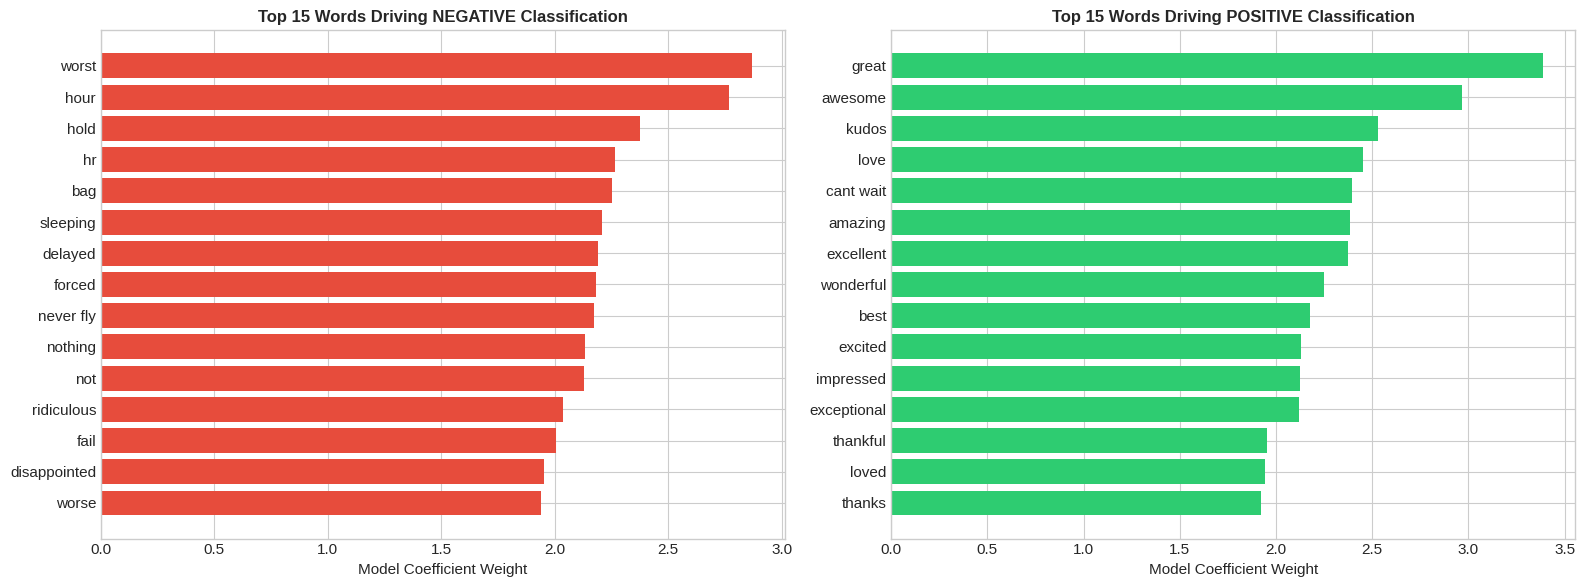

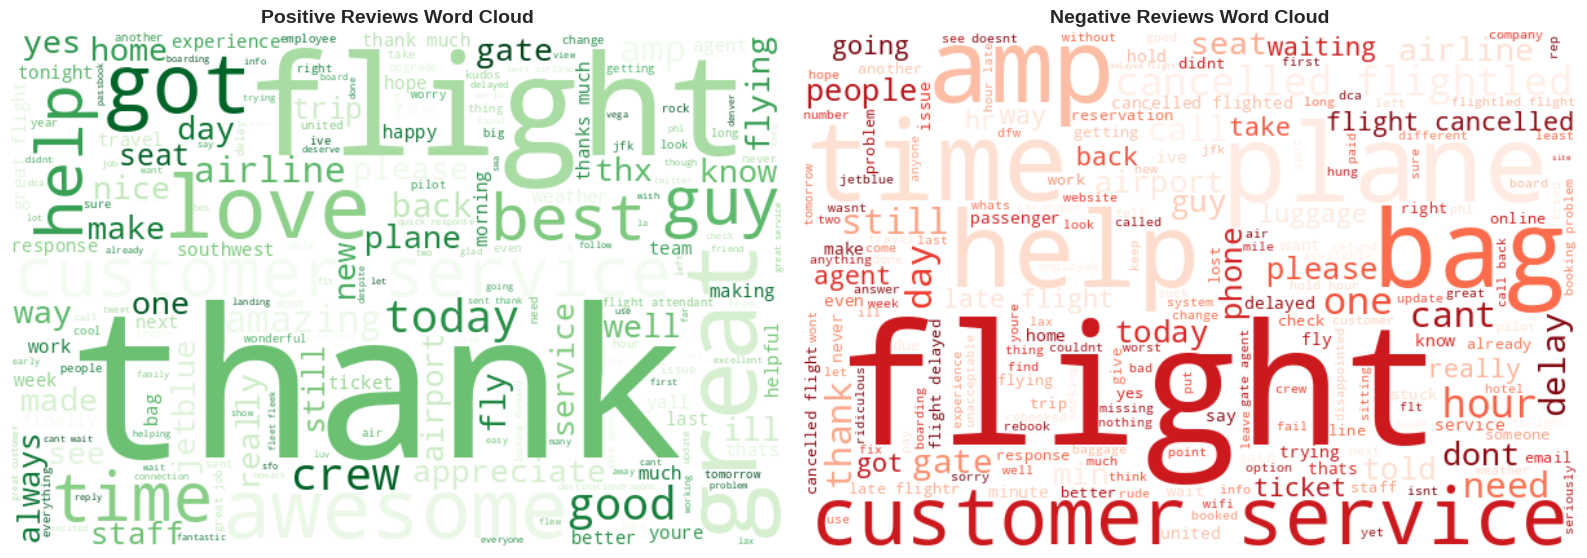

In [41]:
# [Code Cell] Extracting key sentiment features and generating Word Clouds

# Feature Importance from Linear SVM
feature_names = np.array(tfidf_vec.get_feature_names_out())
coefs = svm_model.coef_ # Shape: (n_classes, n_features)

top_neg_indices = np.argsort(coefs[0])[-15:] # Top negative indicators
top_pos_indices = np.argsort(coefs[2])[-15:] # Top positive indicators

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(feature_names[top_neg_indices], coefs[0][top_neg_indices], color='#e74c3c')
axes[0].set_title('Top 15 Words Driving NEGATIVE Classification', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Model Coefficient Weight')

axes[1].barh(feature_names[top_pos_indices], coefs[2][top_pos_indices], color='#2ecc71')
axes[1].set_title('Top 15 Words Driving POSITIVE Classification', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model Coefficient Weight')

plt.tight_layout()
plt.show()

# WordCloud Generation
pos_text = " ".join(df[df['airline_sentiment']=='positive']['clean_text'])
neg_text = " ".join(df[df['airline_sentiment']=='negative']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wordcloud_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(pos_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews Word Cloud', fontsize=14, fontweight='bold')

wordcloud_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(neg_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews Word Cloud', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Cell 11: Business Strategic Recommendations & Presentation Guide**

In [42]:
print("""## Executive Insights & Strategic Business Recommendations

Based on the empirical findings from our machine learning pipeline and feature interpretability analysis:

1. **Service Failure Mitigation (Customer Service Issues)**:
   - *Finding*: \"Customer Service Issue\", \"Late Flight\", and \"Cancelled Flight\" constitute over **60%** of all negative reviews.
   - *Action*: Implement automated proactive notification triggers during flight delays to reduce inbound customer support congestion.

2. **Real-time Social Escalation Pipeline**:
   - *Finding*: The Linear SVM model achieved **~80% accuracy** and a high weighted F1-score in detecting negative sentiment in real-time.
   - *Action*: Route reviews tagged with `negative` sentiment and high confidence directly to high-priority customer service queues.""")

## Executive Insights & Strategic Business Recommendations

Based on the empirical findings from our machine learning pipeline and feature interpretability analysis:

1. **Service Failure Mitigation (Customer Service Issues)**:
   - *Finding*: "Customer Service Issue", "Late Flight", and "Cancelled Flight" constitute over **60%** of all negative reviews.
   - *Action*: Implement automated proactive notification triggers during flight delays to reduce inbound customer support congestion.

2. **Real-time Social Escalation Pipeline**:
   - *Finding*: The Linear SVM model achieved **~80% accuracy** and a high weighted F1-score in detecting negative sentiment in real-time.
   - *Action*: Route reviews tagged with `negative` sentiment and high confidence directly to high-priority customer service queues.
